# Day 3 - Feature Engineering Analysis


## 1. Imports and load dataset

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("../data/processed/modeling_dataset_v1.csv")

print(f"Shape: {df.shape}")
df.head()

Shape: (96470, 38)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,avg_product_height_cm,avg_product_width_cm,avg_product_volume_cm3,sla_breached,estimated_delivery_days,actual_delivery_days,delivery_delay_days,purchase_day_of_week,purchase_hour,is_weekend_order
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,...,9.0,14.0,3528.0,0,15.625671,7.614421,-8.011250,2,8,0
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,...,30.0,40.0,60000.0,0,18.546458,16.216181,-2.330278,2,10,0
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,...,13.0,33.0,14157.0,0,21.393391,7.948437,-13.444954,6,14,1
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,...,10.0,15.0,2400.0,0,11.582928,6.147269,-5.435660,2,10,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226,...,40.0,30.0,42000.0,0,40.418160,25.114352,-15.303808,5,13,1


## 2. Column Categorization

In [4]:
id_columns = [
    'order_id',
    'customer_id',
    'customer_unique_id',
    'primary_product_id',
    'primary_seller_id'
]

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

location_columns = [
    'customer_zip_code_prefix',
    'customer_city',
    'customer_state',
    'primary_seller_zip_code_prefix',
    'primary_seller_city',
    'primary_seller_state'
]

product_columns = [
    'item_count',
    'product_count',
    'product_category_count',
    'primary_product_category_name',
    'avg_product_weight_g',
    'avg_product_length_cm',
    'avg_product_height_cm',
    'avg_product_width_cm',
    'avg_product_volume_cm3'
]

target_column = ['sla_breached']

eda_only_columns = [
    'estimated_delivery_days',
    'actual_delivery_days',
    'delivery_delay_days'
]

other_columns = [
    col for col in df.columns
    if col not in (
        id_columns
        + date_columns
        + location_columns
        + product_columns
        + target_column
        + eda_only_columns
    )
]

print("Other Columns:", other_columns)

Other Columns: ['order_status', 'seller_count', 'total_price', 'avg_price', 'total_freight_value', 'avg_freight_value', 'purchase_day_of_week', 'purchase_hour', 'is_weekend_order']


## 3. SLA Breach Analysis by Customer State

In [5]:
customer_state_analysis = (
    df.groupby('customer_state')['sla_breached']
      .mean()
      .sort_values(ascending=False)
      .mul(100)
      .round(2)
)

customer_state_analysis.head(10)

customer_state
AL    23.93
MA    19.67
PI    15.97
CE    15.32
SE    15.22
BA    14.04
RJ    13.47
TO    12.77
PA    12.37
ES    12.23
Name: sla_breached, dtype: float64

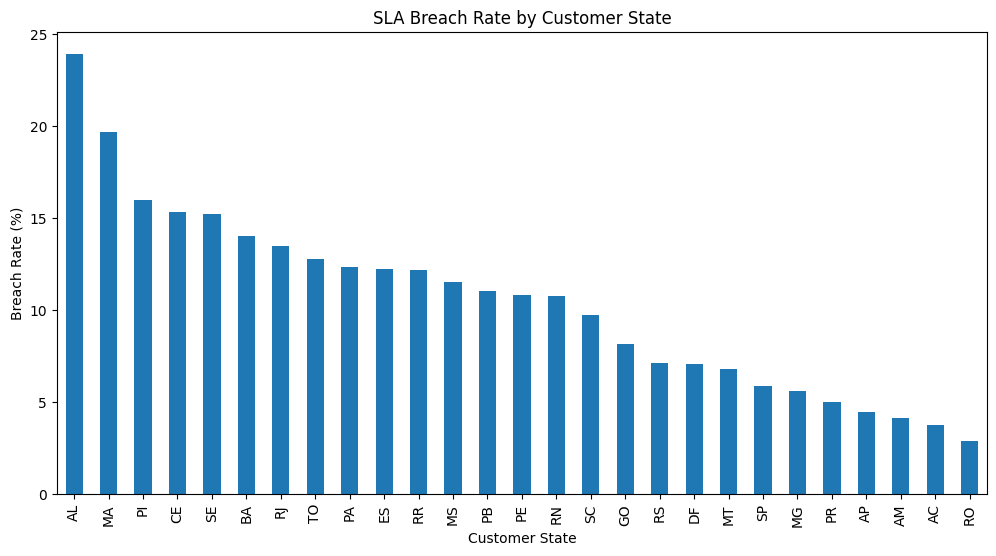

In [8]:
plt.figure(figsize=(12,6))

customer_state_analysis.plot(kind='bar')

plt.title('SLA Breach Rate by Customer State')
plt.ylabel('Breach Rate (%)')
plt.xlabel('Customer State')

plt.show()

In [15]:
df['customer_state'].value_counts().loc['AL']

np.int64(397)

## 4. SLA Breach Analysis by Seller State

In [11]:
seller_state_analysis = (
    df.groupby("primary_seller_state")["sla_breached"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

seller_state_analysis.head(10)

primary_seller_state
AM    66.67
MA    23.20
PA    12.50
RN     9.80
CE     9.41
SP     8.77
MS     8.51
RJ     8.46
ES     7.14
PR     6.53
Name: sla_breached, dtype: float64

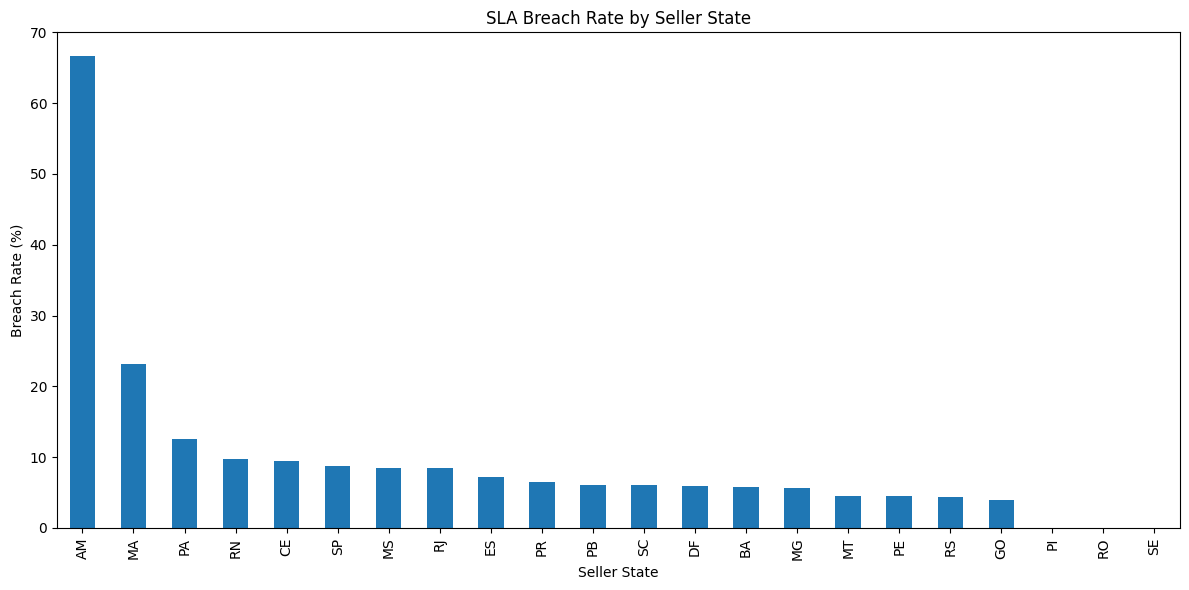

In [13]:
plt.figure(figsize=(12, 6))

seller_state_analysis.plot(kind="bar")

plt.title("SLA Breach Rate by Seller State")
plt.xlabel("Seller State")
plt.ylabel("Breach Rate (%)")

plt.tight_layout()
plt.show()

There is only 3

In [14]:
df["primary_seller_state"].value_counts().loc["AM"]

np.int64(3)

## 5. SLA Breach Analysis by Purchase Day of Week

In [19]:
df['purchase_day_name'] = pd.to_datetime(
    df['order_purchase_timestamp']
).dt.day_name()

In [25]:
day_analysis = (
    df.groupby('purchase_day_name')['sla_breached']
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

day_analysis

purchase_day_name
Monday       9.05
Tuesday      8.49
Friday       8.45
Wednesday    7.80
Saturday     7.60
Thursday     7.57
Sunday       7.49
Name: sla_breached, dtype: float64

In [28]:
df["purchase_day_name"].value_counts()

purchase_day_name
Monday       15701
Tuesday      15502
Wednesday    15074
Thursday     14322
Friday       13684
Sunday       11632
Saturday     10555
Name: count, dtype: int64

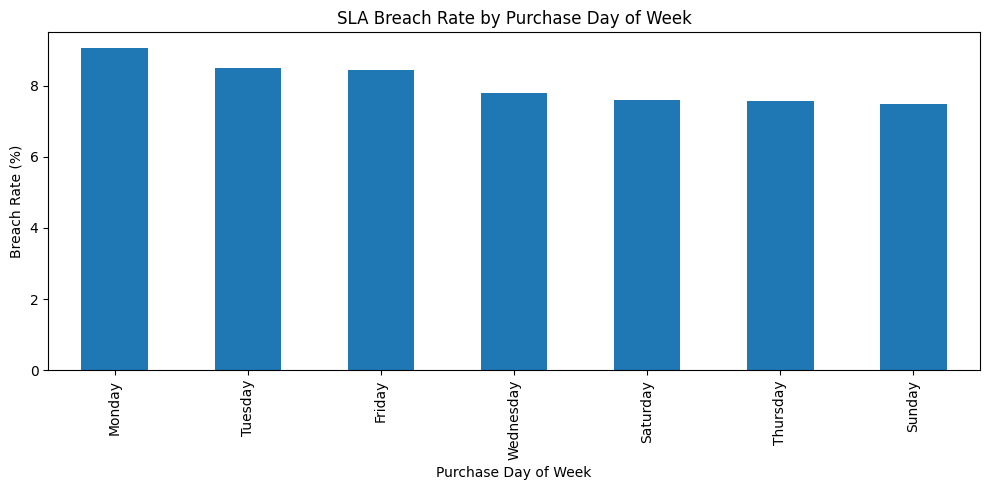

In [29]:
plt.figure(figsize=(10, 5))

day_analysis.plot(kind="bar")

plt.title("SLA Breach Rate by Purchase Day of Week")
plt.xlabel("Purchase Day of Week")
plt.ylabel("Breach Rate (%)")

plt.tight_layout()
plt.show()

## 6. SLA Breach Analysis by Weekend vs Weekday

In [34]:
weekend_analysis = (
    df.groupby("is_weekend_order")["sla_breached"]
      .mean()
      .mul(100)
      .round(2)
)

weekend_analysis

is_weekend_order
0    8.28
1    7.54
Name: sla_breached, dtype: float64

In [36]:
weekend_analysis.index = weekend_analysis.index.map({
    0: "Weekday",
    1: "Weekend"
})

weekend_analysis

is_weekend_order
Weekday    8.28
Weekend    7.54
Name: sla_breached, dtype: float64

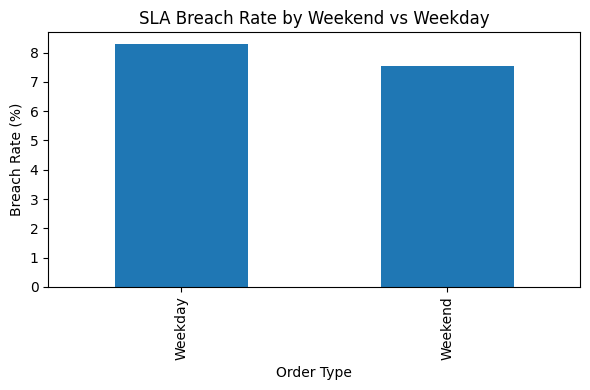

In [37]:
plt.figure(figsize=(6, 4))

weekend_analysis.plot(kind="bar")

plt.title("SLA Breach Rate by Weekend vs Weekday")
plt.xlabel("Order Type")
plt.ylabel("Breach Rate (%)")

plt.tight_layout()
plt.show()

## 7. SLA Breach Analysis by Product Category Name

In [38]:
df["primary_product_category_name"].nunique()

74

In [39]:
df["primary_product_category_name"].value_counts().head(10)

primary_product_category_name
cama_mesa_banho           9167
beleza_saude              8608
esporte_lazer             7490
informatica_acessorios    6500
moveis_decoracao          6213
utilidades_domesticas     5688
relogios_presentes        5470
telefonia                 4076
automotivo                3792
brinquedos                3778
Name: count, dtype: int64

In [40]:
top_10_categories = (
    df["primary_product_category_name"]
      .value_counts()
      .head(10)
      .index
)

top_10_categories

Index(['cama_mesa_banho', 'beleza_saude', 'esporte_lazer',
       'informatica_acessorios', 'moveis_decoracao', 'utilidades_domesticas',
       'relogios_presentes', 'telefonia', 'automotivo', 'brinquedos'],
      dtype='str', name='primary_product_category_name')

In [41]:
top_category_df = df[
    df["primary_product_category_name"].isin(top_10_categories)
]

In [42]:
category_analysis = (
    top_category_df
      .groupby("primary_product_category_name")["sla_breached"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

category_analysis

primary_product_category_name
beleza_saude              8.99
cama_mesa_banho           8.85
automotivo                8.65
moveis_decoracao          8.56
relogios_presentes        8.56
telefonia                 8.54
esporte_lazer             7.80
informatica_acessorios    7.74
brinquedos                7.52
utilidades_domesticas     7.00
Name: sla_breached, dtype: float64

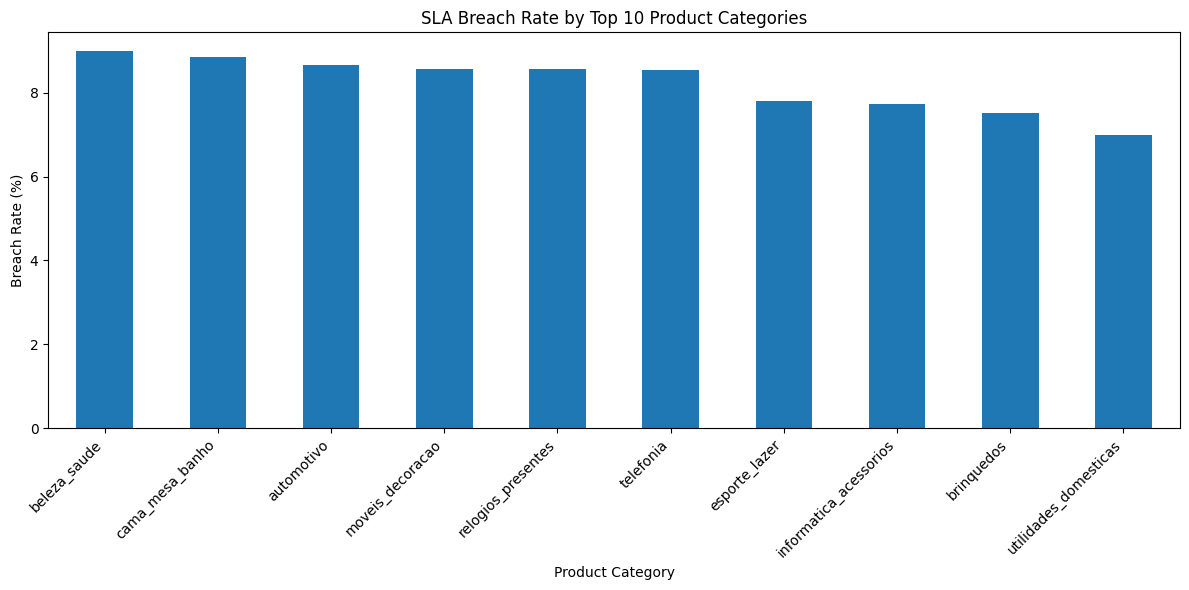

In [43]:
plt.figure(figsize=(12, 6))

category_analysis.plot(kind="bar")

plt.title("SLA Breach Rate by Top 10 Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Breach Rate (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 8. SLA Breach Analysis by Product Weight Bucket

In [44]:
df["avg_product_weight_g"].describe()

count    96454.000000
mean      2098.270555
std       3745.020041
min          0.000000
25%        300.000000
50%        700.000000
75%       1800.000000
max      40425.000000
Name: avg_product_weight_g, dtype: float64

In [45]:
weight_bins = [0, 500, 1000, 2000, 5000, float("inf")]

weight_labels = [
    "0-500g",
    "500-1000g",
    "1000-2000g",
    "2000-5000g",
    "5000g+"
]

df["weight_bucket"] = pd.cut(
    df["avg_product_weight_g"],
    bins=weight_bins,
    labels=weight_labels,
    include_lowest=True
)

In [46]:
df["weight_bucket"].value_counts()

weight_bucket
0-500g        40780
500-1000g     17193
1000-2000g    16441
5000g+        11978
2000-5000g    10062
Name: count, dtype: int64

In [49]:
weight_analysis = (
    df.groupby("weight_bucket")["sla_breached"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

weight_analysis

weight_bucket
5000g+        9.18
2000-5000g    8.53
1000-2000g    8.40
0-500g        7.75
500-1000g     7.71
Name: sla_breached, dtype: float64

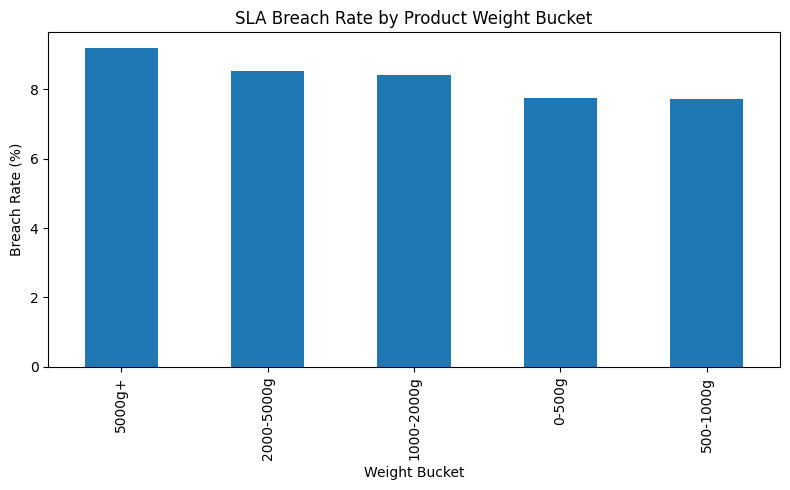

In [50]:
plt.figure(figsize=(8, 5))

weight_analysis.plot(kind="bar")

plt.title("SLA Breach Rate by Product Weight Bucket")
plt.xlabel("Weight Bucket")
plt.ylabel("Breach Rate (%)")

plt.tight_layout()
plt.show()

## 9. SLA Breach Analysis by Freight Value Bucket

In [53]:
df["total_freight_value"].describe()

count    96470.000000
mean        22.785798
std         21.559959
min          0.000000
25%         13.850000
50%         17.170000
75%         24.020000
max       1794.960000
Name: total_freight_value, dtype: float64

In [ ]:
freight_bins = [0, 10, 20, 30, 50, float("inf")]

freight_labels = [
    "0-10",
    "10-20",
    "20-30",
    "30-50",
    "50+"
]

df["freight_bucket"] = pd.cut(
    df["total_freight_value"],
    bins=freight_bins,
    labels=freight_labels,
    include_lowest=True
)

In [55]:
df["freight_bucket"].value_counts()

freight_bucket
10-20    52394
20-30    16309
0-10     11073
30-50    10623
50+       6071
Name: count, dtype: int64

In [56]:
freight_analysis = (
    df.groupby("freight_bucket")["sla_breached"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

freight_analysis

freight_bucket
50+      9.90
30-50    9.25
20-30    9.06
10-20    7.78
0-10     6.22
Name: sla_breached, dtype: float64

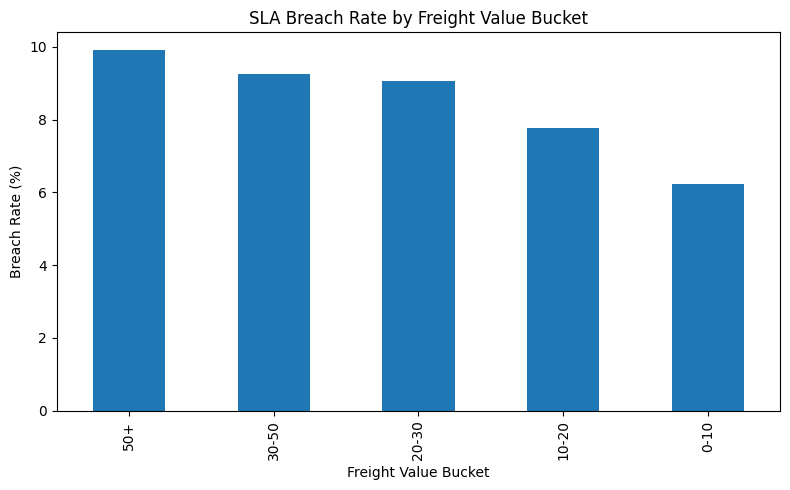

In [57]:
plt.figure(figsize=(8, 5))

freight_analysis.plot(kind="bar")

plt.title("SLA Breach Rate by Freight Value Bucket")
plt.xlabel("Freight Value Bucket")
plt.ylabel("Breach Rate (%)")

plt.tight_layout()
plt.show()